In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('Telco_customer_churn/Telco_Customer_Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Here, we found that total charges column has blank by viewing its data in excel. And while watching other columns too, it is seen that they have 0 tenure month. So, we can replace blank in total charges with 0.

Also, we convert dtype of total charges to float as it was in object.

In [18]:
df['TotalCharges'] = df["TotalCharges"].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
df.isnull().sum().sum()

0

In [31]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [37]:
df["customerID"].duplicated().sum()

0

In [43]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

Converted 0 and 1 value of SeniorCitizen to yes and no  

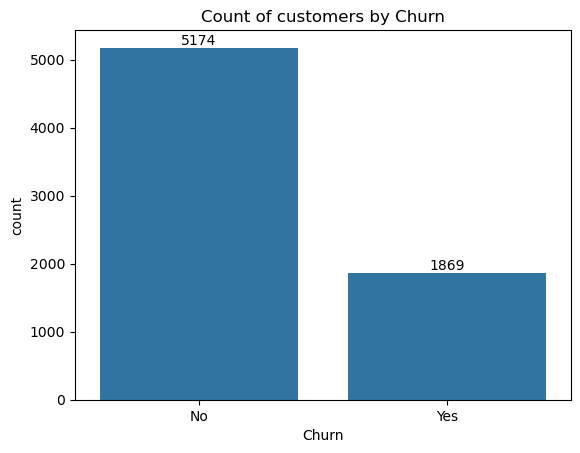

In [88]:
ax = sns.countplot(x = df['Churn'],data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

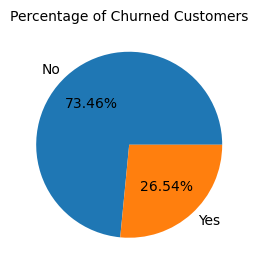

In [92]:
plt.figure(figsize=(3,4))
churn_gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(churn_gb['Churn'],labels=churn_gb.index,autopct="%1.2f%%")
plt.title("Percentage of Churned Customers",fontsize = 10)
plt.show()


From the above piechart, we can know that 26.54 % of customers had churned out.

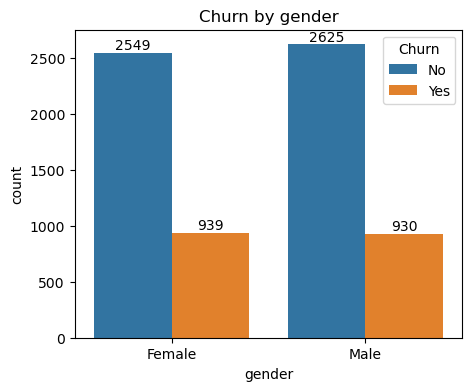

In [147]:
plt.figure(figsize=(5,4))
plt.title("Churn by gender")
ax=sns.countplot(x="gender",data = df,hue="Churn")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

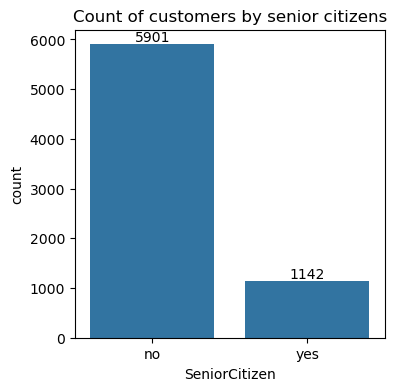

In [163]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="SeniorCitizen",data=df)
plt.title("Count of customers by senior citizens")
for container in ax.containers:
    ax.bar_label(container)

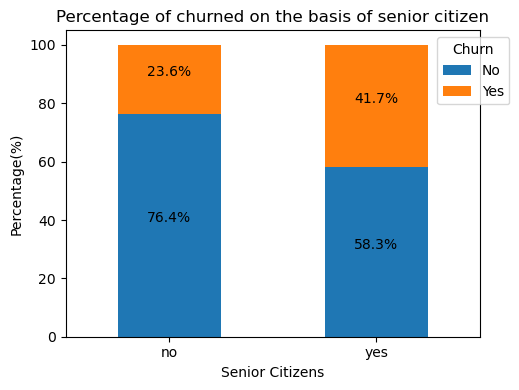

In [214]:
total_counts = df.groupby("SeniorCitizen")["Churn"].value_counts(normalize=True).unstack()*100

fig,ax = plt.subplots(figsize=(5,4))
total_counts.plot(kind='bar',stacked=True,ax=ax)
for p in ax.patches:
    width,height=p.get_width(),p.get_height()
    x,y = p.get_xy()
    ax.text(x+width / 2,y+height / 2,f'{height:.1f}%',ha='center',va='bottom')
plt.title("Percentage of churned on the basis of senior citizen")
plt.ylabel("Percentage(%)")
plt.xlabel("Senior Citizens")
plt.xticks(rotation=0)
plt.tight_layout()
plt.legend(title='Churn',bbox_to_anchor=(0.88,1))

Here, churning out of customers is relatively more in senior citizens.

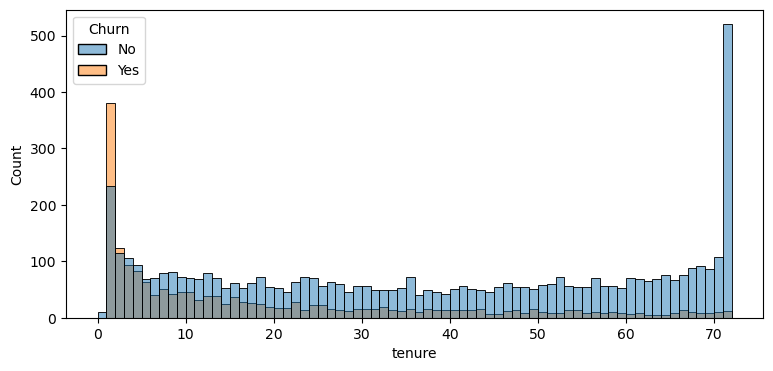

In [242]:
plt.figure(figsize=(9,4))
ax=sns.histplot(x="tenure",data=df,bins=72,hue="Churn")
plt.show()

Customers tend to churn out during the initial months and the old 
customers tends to stay more longer. This indicates that there is early dissatisfaction or onboarding issue.

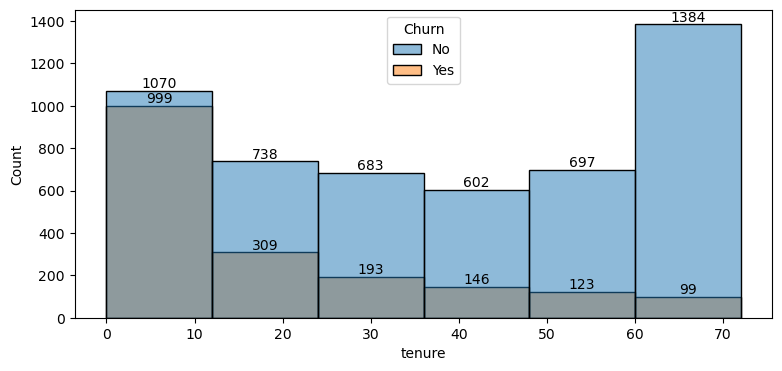

In [238]:
plt.figure(figsize=(9,4))
ax=sns.histplot(x="tenure",data=df,bins=6,hue="Churn")
ax.bar_label(ax.containers[0])  # Label "No" bars
ax.bar_label(ax.containers[1])
plt.show()

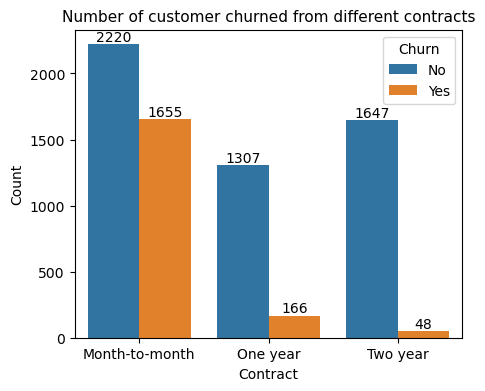

In [262]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Contract',data=df,hue="Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xlabel("Contract")
plt.ylabel("Count")
plt.title("Number of customer churned from different contracts",fontsize=11)
plt.show()

Customers who have taken month to month contracts tends to churn out more than yearly based contracts.

In [265]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

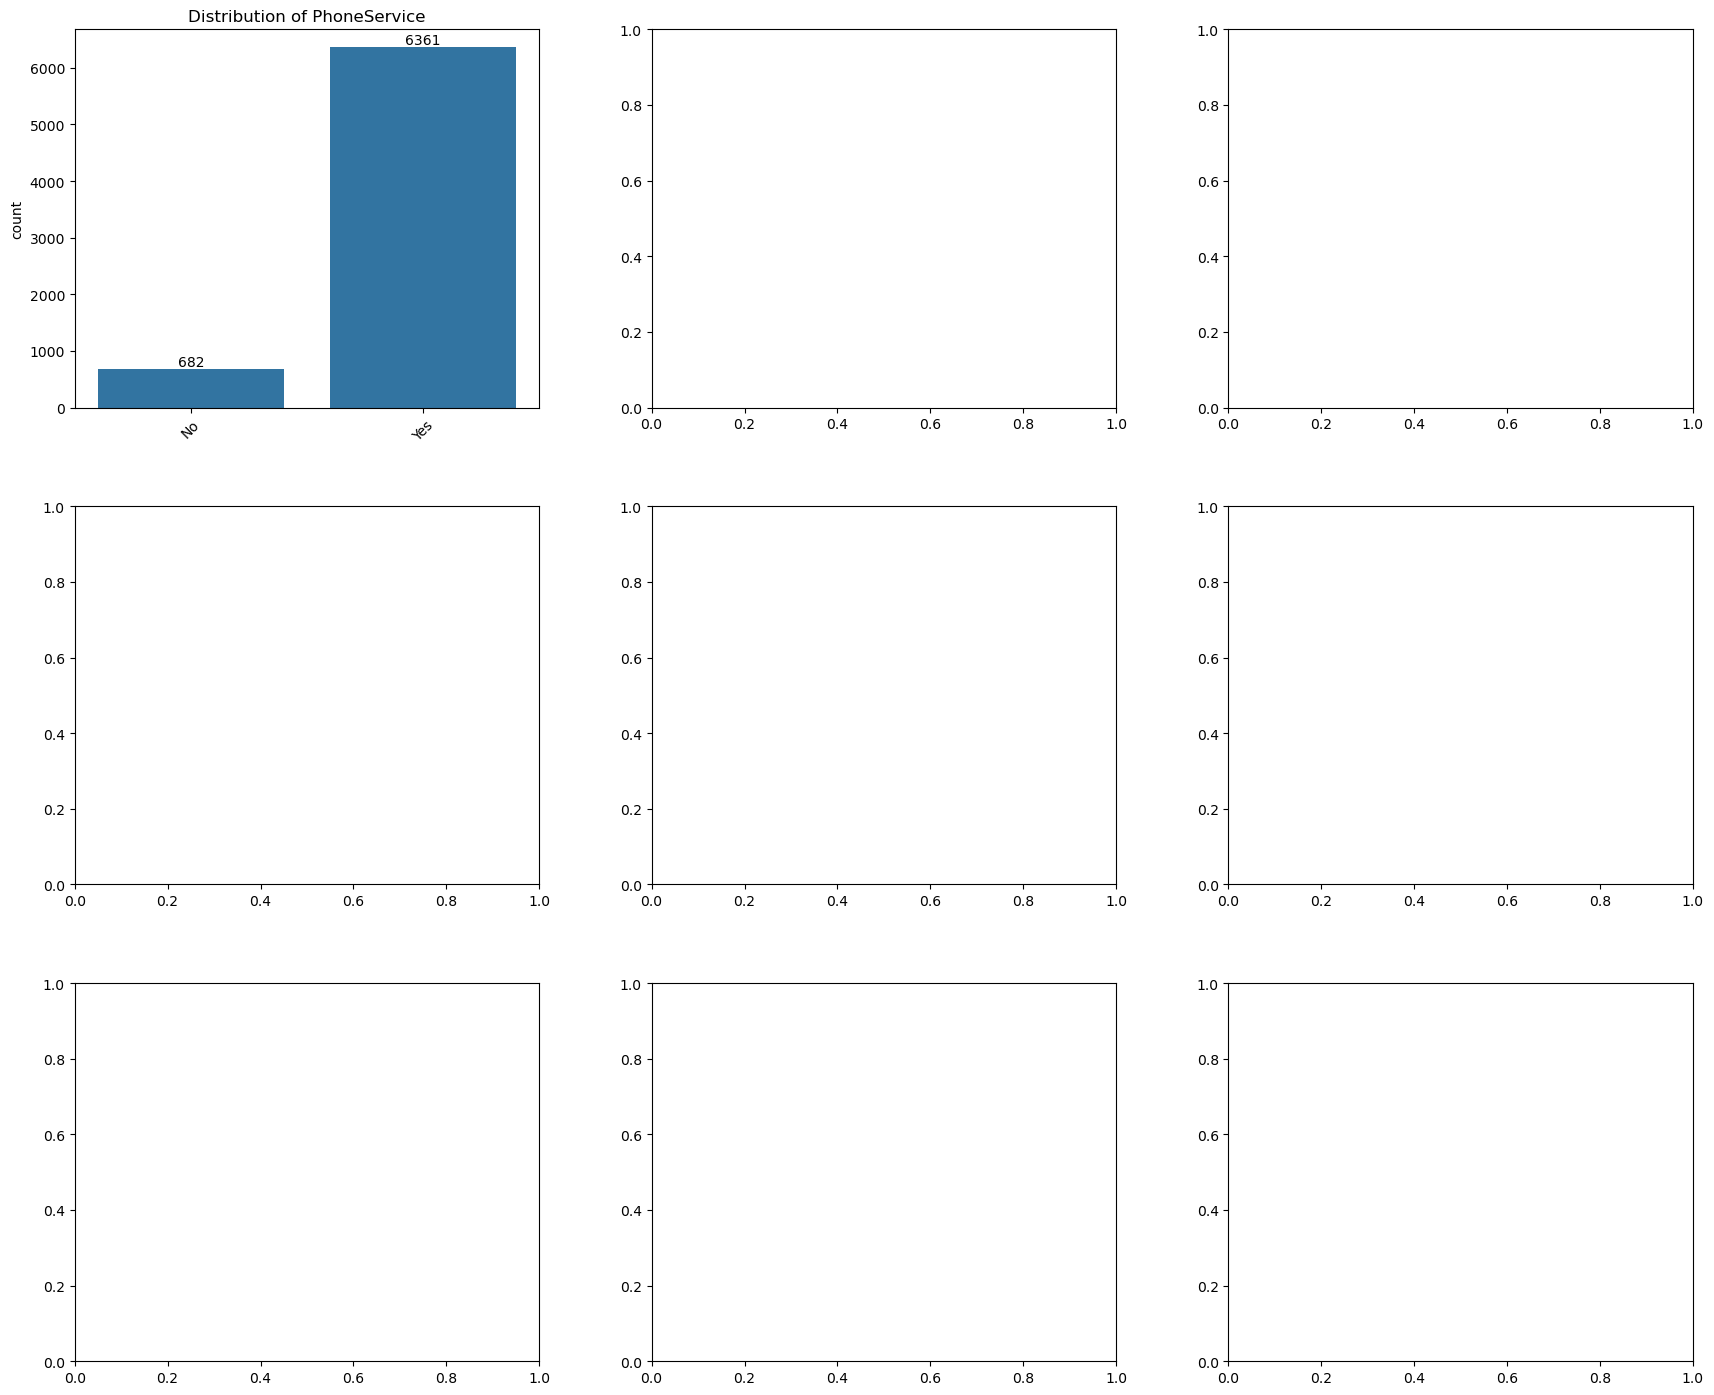

In [273]:
categorical_columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
fig.tight_layout(pad=5.0)  # Add spacing between subplots

for i, column in enumerate(categorical_columns):
    row = i // 3  # Row index (0, 1, 2)
    col = i % 3    # Column index (0, 1, 2)
    ax = axes[row, col]
    
    # Ensure column is treated as categorical
    if df[column].dtype == 'object':
        sns.countplot(x=column, data=df, ax=ax)
    else:
        sns.countplot(x=column.astype('category'), data=df, ax=ax)  # Force categorical
    
    ax.set_title(f'Distribution of {column}', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    
    # Add count labels
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.0f}', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', xytext=(0, 5), textcoords='offset points'
        )
    plt.show()

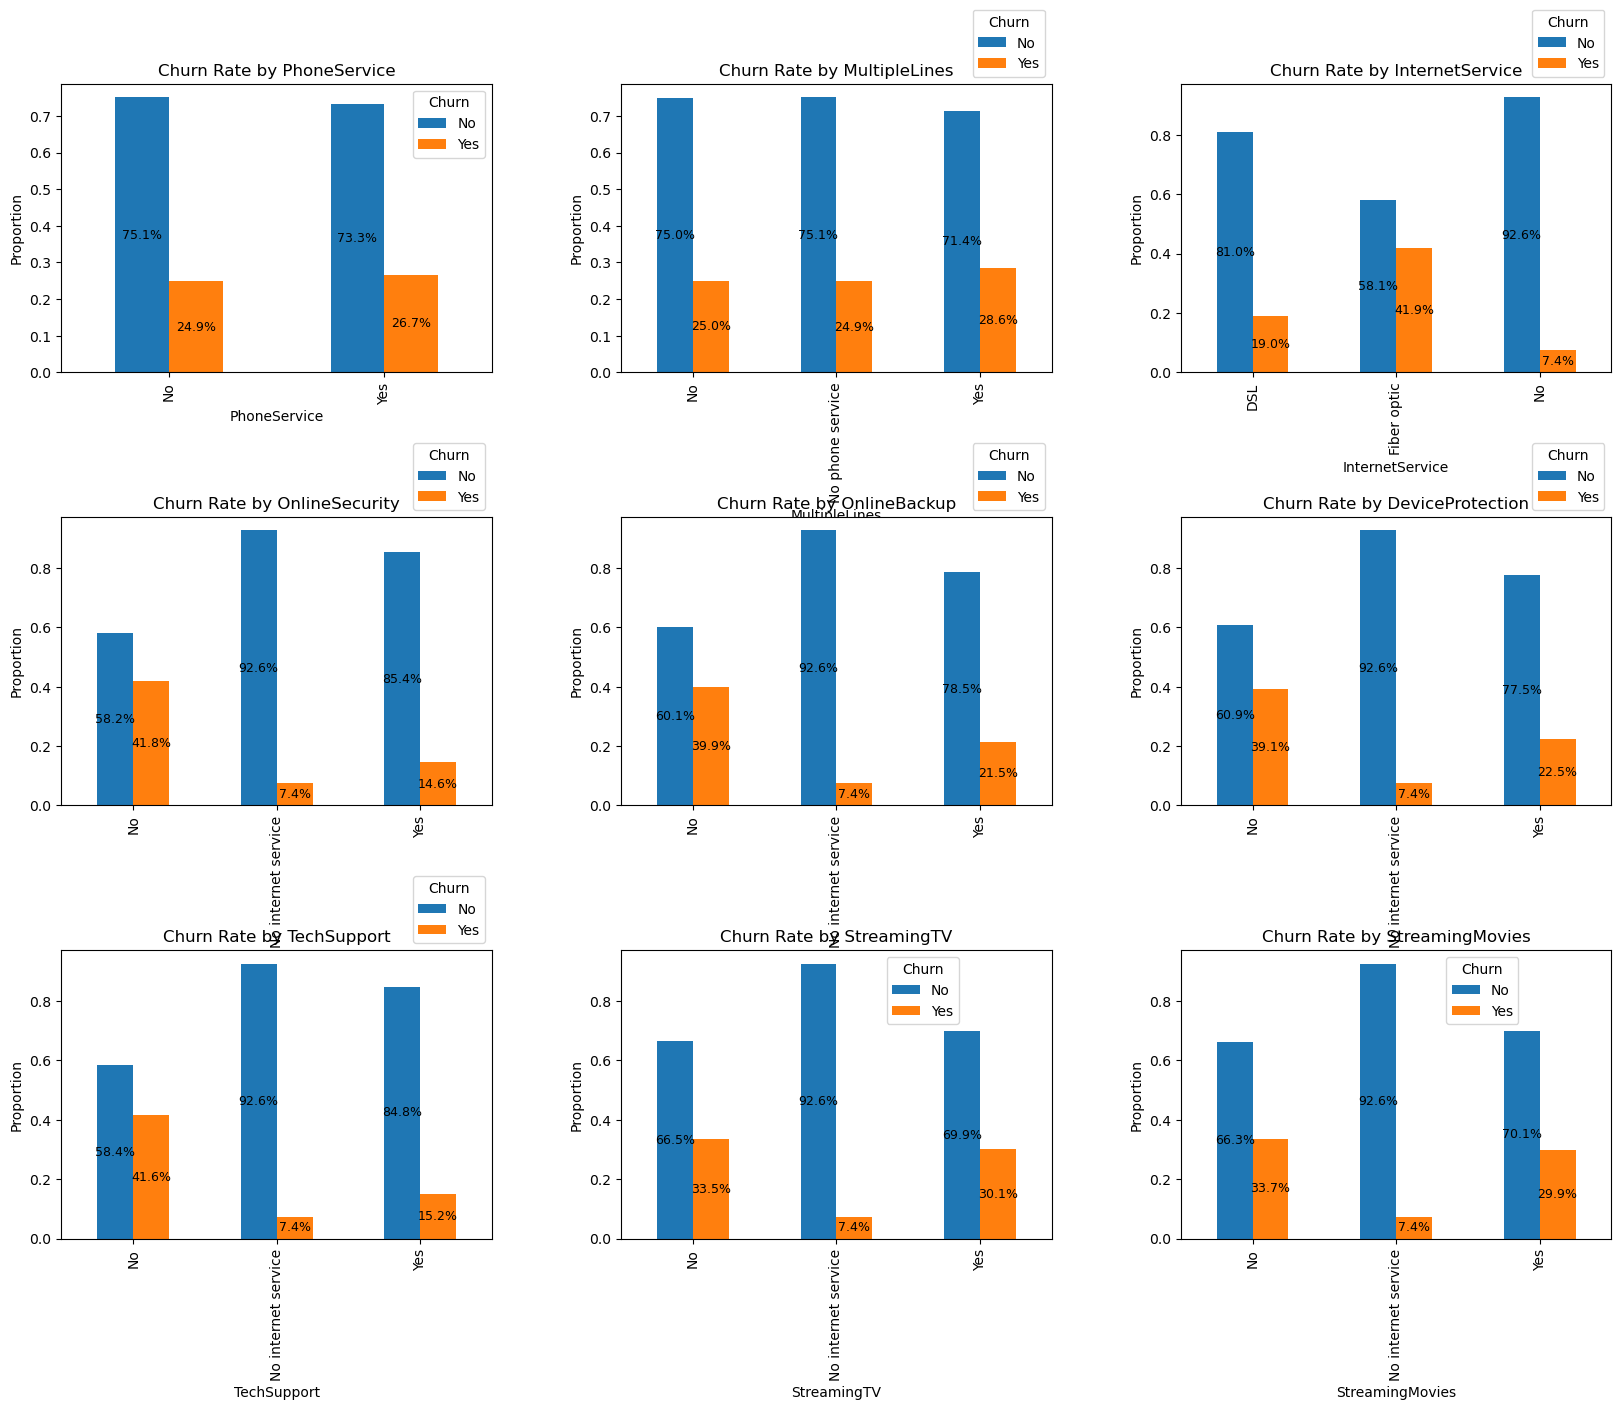

In [283]:


# List of service columns
services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Set up subplots
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i, service in enumerate(services):
    row, col = i // 3, i % 3
    ax = axes[row, col]
    
    # Create a normalized stacked bar plot
    pd.crosstab(df[service], df['Churn'], normalize='index').plot(
        kind='bar', stacked=False, ax=ax, color=['#1f77b4', '#ff7f0e']
    )
    
    ax.set_title(f'Churn Rate by {service}', fontsize=12)
    ax.set_ylabel('Proportion')
    ax.legend(title='Churn', bbox_to_anchor=(0.8, 1))
    
    # Add percentage labels
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        ax.text(x + width/2, y + height/2, f'{height:.1%}', 
                ha='center', va='center', fontsize=9)

plt.show()